# Lab 4\. Devices: Checking, Placing, and Moving Tensors

## Overview

In the chapter, you learned that every tensor lives on a device (the hardware where its numbers sit and where operations on it run) and that PyTorch supports three device types: the CPU, a CUDA NVIDIA GPU, and Apple Silicon through MPS. You also saw the rule that decides whether two tensors can work together: they must be on the same device, or PyTorch raises an error rather than guessing. This lab turns those ideas into something you do rather than read about.

Working in a notebook, you will check which devices your own environment offers, load the rock-paper-scissors images as tensors, and move them onto the best available device with **.to()**. You will then cause the most common device error on purpose, read what it tells you, and fix it by putting both tensors on the same device. The lab closes with the device-agnostic selection block: a few lines that pick the best hardware automatically and route everything to it, so the same notebook runs unchanged on a GPU machine, on a Mac, or on a plain CPU.

Every PyTorch program that uses a GPU has to solve this placement problem, and getting it wrong is one of the first errors a new practitioner meets. The pattern you build here is the exact one you will use in the next chapter, where you move both a model and its training data onto one device before training. Learning it now, by hand, means the device mechanics will not be in your way when you are focused on training a model.

## Learning Objectives

By the end of this lab, you should be able to:

* Check device availability for CPU, CUDA, and MPS in a PyTorch notebook environment  
* Load the rock-paper-scissors images as tensors and read their **device** property  
* Move tensors to a chosen device with **.to()**, and use the **.cuda()** / **.cpu()** shortcuts  
* Reproduce the "expected all tensors to be on the same device" error and resolve it by aligning devices  
* Write a reusable device-agnostic selection block that chooses CUDA, then MPS, then CPU

## Prerequisites

This course’s labs are **not cumulative**, so this lab does not depend on any prior resources or the state of earlier labs if there are any.

Before starting, make sure you have the following:

* **A notebook environment:** either a Google account for Google Colab, or a local installation of Jupyter Notebook. This lab requires a CUDA GPU (in Colab, select “T4 GPU” in **Runtime \> Change runtime type \> Hardware accelerator**).

* **Python 3.12 or later.** On Colab this is already provided. For a local environment, confirm your version with **python \--version**.

* **PyTorch 2.12.1 and TorchVision 0.27,** installed with **pip** in the first setup step below. If you are on Colab, these may already be present; the setup step confirms the versions.

* **Network access to the LFD2000-resources course repository,** which hosts the rock-paper-scissors image dataset. The setup step downloads it.

* **A web browser** (Chrome, Firefox, or Edge are recommended for Colab).

## Estimated Time

25–35 minutes.



## How to Perform the Exercise

You will work entirely in one notebook, running cells from top to bottom. Create a new notebook in Google Colab (**File \> New notebook**) or a new **.ipynb** in local Jupyter. Download the chapter 4 lab notebook from the [LFD2000-resources GitHub repository](https://github.com/lftraining/LFD2000-resources.git) from the **LFD2000-resources/labs** directory. In Google Colab, select File, then Upload Notebook, and select the chapter 4 lab notebook you downloaded.

Read the explanation before running each cell, run it, and compare what you see to the **Sample Output** or **Output** shown after each block. Sample Output means the exact values will differ from run to run (random tensors, dataset counts, file paths), so match the shape and structure rather than every character. Output marks a checkpoint where a specific outcome confirms the step worked.

The rock-paper-scissors images come from the [LFD2000-resources GitHub repository](https://github.com/lftraining/LFD2000-resources.git), which you clone in Setup 2\. That repository holds the dataset under **LFD2000-resources/datasets/RPS/train**, organized as one folder per class (rock, paper, and scissors). You do not modify any files in the dataset; you only read the images and turn them into tensors.

Commands in this lab use the notebook form, where a line beginning with **\!** runs a shell command from inside a notebook cell (for example, **\!pip install ...**). If you run these in a local terminal instead of a notebook cell, drop the leading **\!**.

> **Note:** Run the cells in order and only once each, unless a step says otherwise. If you restart the notebook's runtime, re-run the cells from the top, because the variables live in memory and are cleared on restart.  



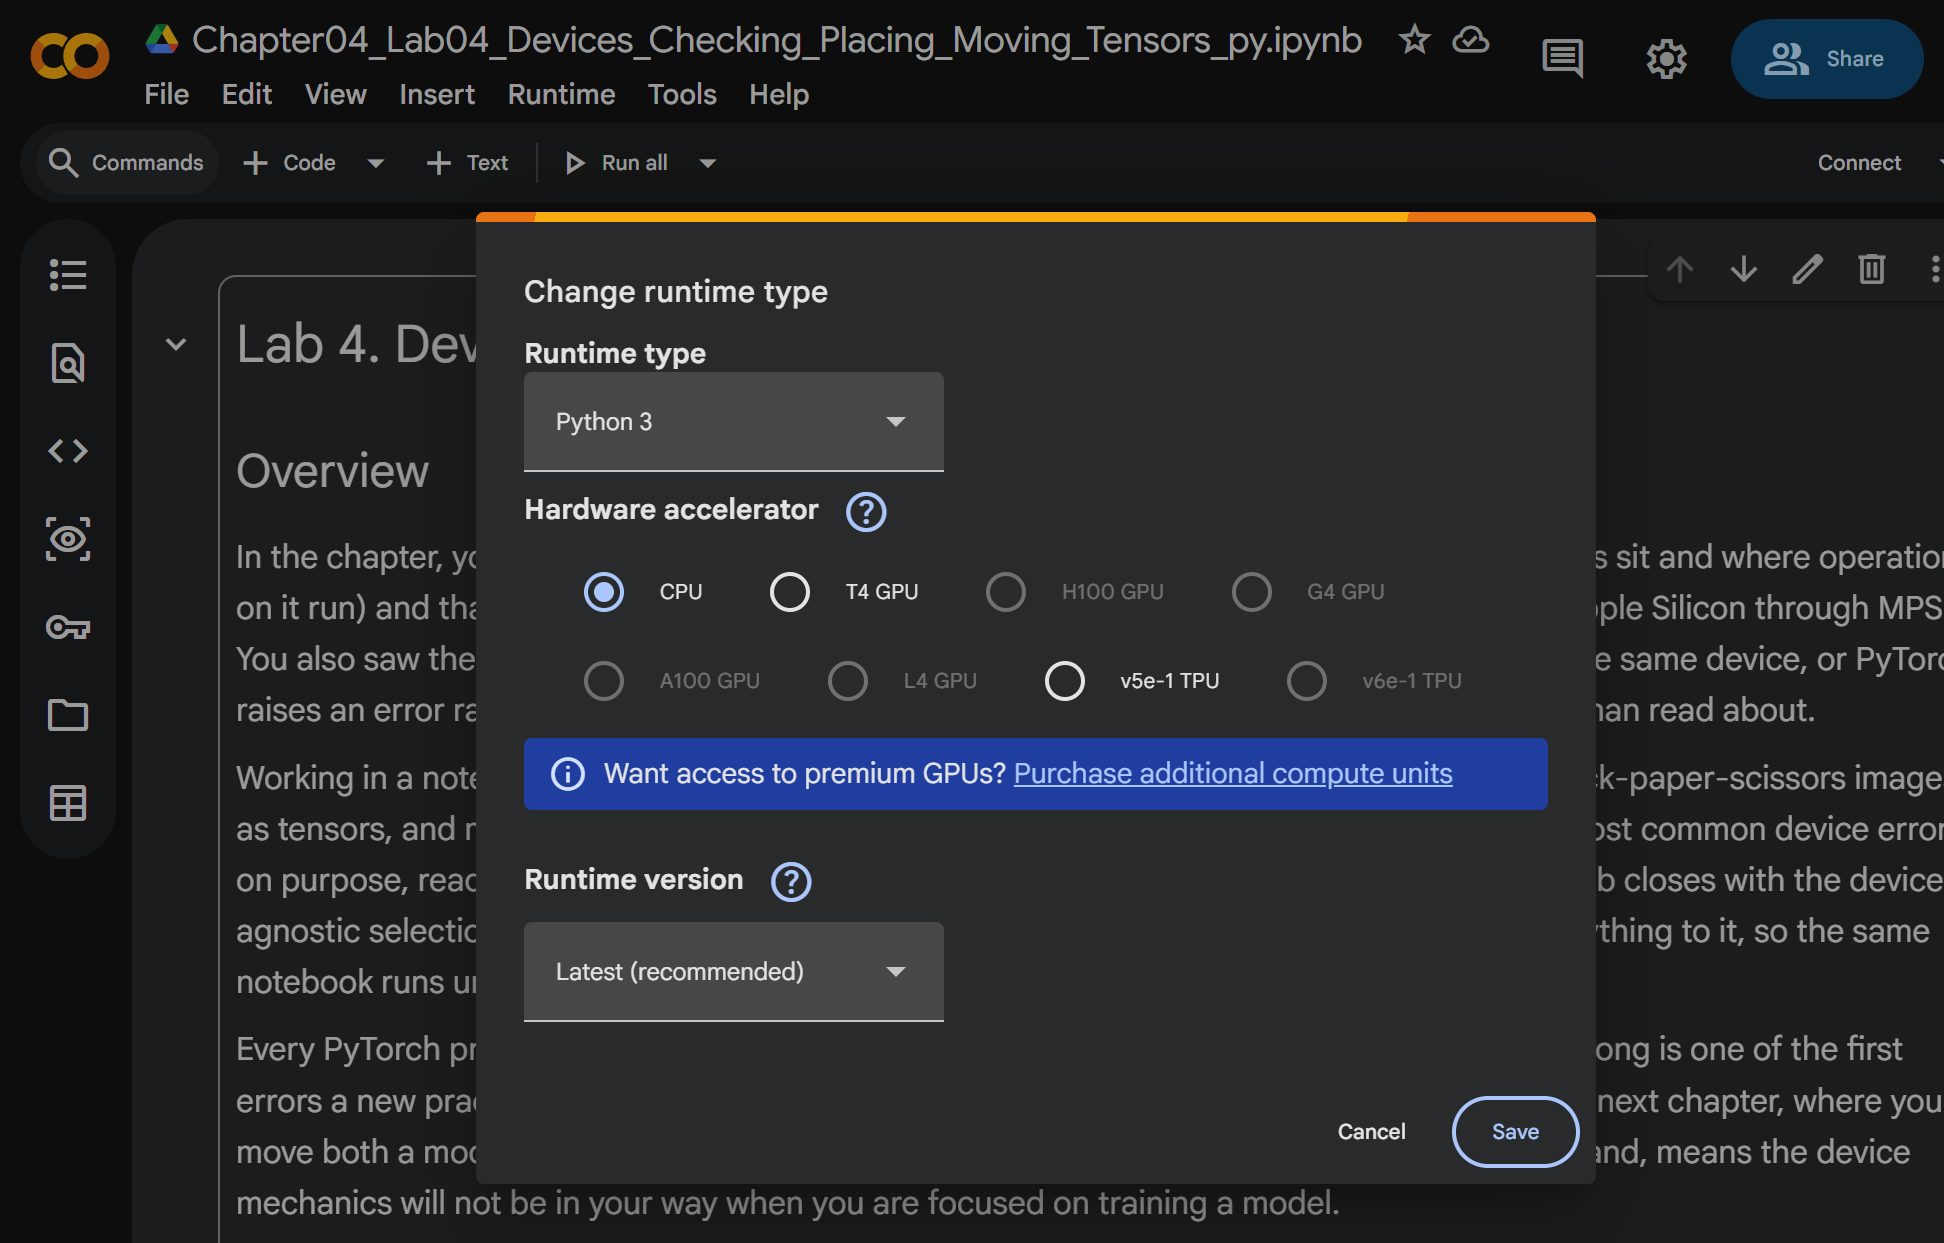
**Change RunTime Type Screenshot**

## Setup: Environment Preparation

The steps in this section only prepare the environment. They are not the learning content of the lab, and on a managed course platform some of them may already be done for you. Run them once at the top of your notebook, then move on to Step 1\.

### Setup 1\. Install PyTorch and TorchVision, and Import

Install the two libraries the lab uses. PyTorch provides tensors and the operations on them; TorchVision provides the image dataset loader and the image transforms used at the end of the lab.

In [ ]:
!pip install torch torchvision


Confirm the versions so your results line up with this lab. Printing the versions now also verifies the import works before you depend on it later.


In [ ]:
import torch
import torchvision

print("PyTorch:", torch.__version__)
print("TorchVision:", torchvision.__version__)


Sample Output:

```
PyTorch: 2.12.1
TorchVision: 0.27.0
```

If your versions are close to these but not identical, the lab still works; the tensor and transform APIs used here are stable across the 2.x line.

Next, import the modules you will use throughout the lab. **torch** is the core library; **v2** is TorchVision's current transforms module; and **ImageFolder** loads images arranged one folder per class.


In [ ]:
import torch
from torchvision.transforms import v2
from torchvision.datasets import ImageFolder



### Setup 2\. Download the Rock-Paper-Scissors Dataset

Download the course dataset so the final steps have real images to work with. The images are organized with one folder per class, which is the layout the **ImageFolder** loader expects later in the lab.


In [ ]:
!git clone https://github.com/lftraining/LFD2000-resources.git


Sample Output

```
Cloning into 'LFD2000-resources'...
remote: Enumerating objects: ...
Receiving objects: 100% ...
Resolving deltas: 100% ...
```

After the clone completes, the images are under **LFD2000-resources/datasets/RPS/train**, with a separate subfolder for each hand pose.

To confirm the dataset is where you expect, list the class folders under the dataset root. You should see one folder per class.


In [ ]:
import os
print(os.listdir("LFD2000-resources/datasets/RPS/train"))


Sample Output

```
['rock', 'paper', 'scissors']
```

Seeing the three class folders confirms the dataset root path is correct, which is the path you hand to **ImageFolder** in Step 4\.

## Working with Devices

The remaining steps are the core of the lab. You will inspect your environment, load real data as tensors, move tensors between devices, break the device rule on purpose, fix it, and finish with the reusable device-agnostic block.

### Step 1\. Check Which Devices Are Available

Before you place a tensor on a GPU, you have to know whether one exists. PyTorch gives you a direct check for each accelerator: **torch.cuda.is\_available()** for an NVIDIA (CUDA) GPU, and **torch.backends.mps.is\_available()** for Apple Silicon (MPS). The CPU is always present, so there is no check for it.


In [ ]:
print("CUDA available:", torch.cuda.is_available())
print("MPS available:", torch.backends.mps.is_available())


Sample Output (on a CPU-only environment, such as a default Colab runtime)

```
CUDA available: False
MPS available: False
```

Sample Output (on a GPU-enabled environment, such as Colab runtime with Tesla T4 GPU)

```
CUDA available: True
MPS available: False
```

Read your own result rather than the sample. On a machine with an NVIDIA GPU, or a Colab GPU runtime, the CUDA line reads **True**. On an Apple Silicon Mac, the MPS line reads **True**. Whatever you see here tells you which accelerators the rest of the lab can use on your machine.

### Step 2\. Load the Rock-Paper-Scissors Images as Tensors

Bring in real data so the device work applies to the course problem rather than to throwaway numbers. You will rebuild the same image-to-tensor pipeline from Chapter 3 and load the images with **ImageFolder**. This is the same pipeline you saw before, recreated here because this lab does not carry anything over from the Chapter 3 lab.

The pipeline chains three transforms with **v2.Compose**: **v2.ToImage()** turns a loaded image into a tensor, **v2.Resize((128, 128))** forces every image to the same height and width, and **v2.ToDtype(torch.float32, scale=True)** converts to PyTorch's default decimal type and rescales pixel values from the 0–255 range to 0.0–1.0.


In [ ]:
to_tensor = v2.Compose([
    v2.ToImage(),
    v2.Resize((128, 128)),
    v2.ToDtype(torch.float32, scale=True),
])

dataset = ImageFolder(root="LFD2000-resources/datasets/RPS/train", transform=to_tensor)
print("Number of images:", len(dataset))
print("Classes:", dataset.classes)


Sample Output

```
Number of images: 2520
Classes: ['paper', 'rock', 'scissors']
```

The image count will match whatever the dataset contains, and **ImageFolder** sorts the class names alphabetically, so do not worry if the ordering differs from how you listed the folders earlier. Now take a single image tensor out of the dataset and inspect it. Each item is a pair: the image tensor and its integer class label.


In [ ]:
image, label = dataset[0]
print("Shape:", image.shape)
print("Dtype:", image.dtype)
print("Device:", image.device)


Output

```
Shape: torch.Size([3, 128, 128])
Dtype: torch.float32
Device: cpu
```

The shape **(3, 128, 128\)** is the image tensor layout from Chapter 3: three color channels, each 128 pixels high and 128 wide. The important line for this lab is the last one: the tensor reports **device: cpu**. Freshly loaded data always starts on the CPU, which is exactly why you will move it before running work on an accelerator.

### Step 3\. Move a Tensor to the Best Available Device

Choose a device to work on, then move the image tensor onto it. For this step, pick CUDA if it is available and fall back to the CPU otherwise, so the code runs anywhere. You move a tensor with **.to()**, which returns a **copy** on the target device.


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

image_on_device = image.to(device)
print("Original image device:", image.device)
print("Moved copy device:", image_on_device.device)


Sample Output (on a CPU-only environment)

```
Using device: cpu
Original image device: cpu
Moved copy device: cpu
```

Sample Output (on a CUDA-enabled environment)

```
Using device: cuda
Original image device: cpu
Moved copy device: cuda:0
```

On a GPU machine, **Using device** reads **cuda**, the original still reads **cpu**, and the moved copy reads **cuda:0**. That contrast is the key point: **.to()** does not change the original tensor in place. It hands back a new tensor on the target device, so you must assign the result to a variable to keep it. Writing **image.to(device)** on its own and then continuing to use **image** would leave you on the old device with nothing moved.

PyTorch also provides two shortcuts: **.cuda()** moves a tensor to a CUDA GPU and **.cpu()** moves it back to the CPU. They behave like **.to("cuda")** and **.to("cpu")**. There is no **.mps()** shortcut, so **.to()** is the one method that works for every device, which is why this lab uses it.

### Step 4\. Trigger the Device Mismatch Error on Purpose

The most common device error appears when a single operation combines tensors that live on different devices. Causing it deliberately, and reading the message, makes it easy to recognize later. This only happens when you actually have a second device to place a tensor on, so the code below runs the experiment when an accelerator is available and explains the situation when it is not. The **try**/**except** wrapper catches the error so your notebook keeps running.


In [ ]:
if device != "cpu":
    a = torch.tensor([1.0, 2.0, 3.0])                 # stays on the CPU
    b = torch.tensor([4.0, 5.0, 6.0], device=device)  # on the accelerator
    try:
        result = a + b
    except RuntimeError as e:
        print("RuntimeError:", e)
else:
    print("No accelerator available, so this mismatch cannot be triggered on CPU alone.")
    print("On a GPU or MPS machine you would see a RuntimeError like the one below:")
    print("Expected all tensors to be on the same device, "
          "but found at least two devices, cuda:0 and cpu!")


Output (on a machine with an accelerator)

```
RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!
```

Read what the message says. It names the exact problem, tensors on more than one device, and it names the two devices involved. Here that is **cuda:0** (where **b** lives) and **cpu** (where **a** lives). The two tensors met in a single addition without sharing a device, so PyTorch stopped instead of guessing which device you meant. If you are on a CPU-only environment, you cannot place **a** and **b** on different devices, so the code prints the message you would see on an accelerator instead.

### Step 5\. Fix the Mismatch by Aligning Devices

The fix is to put both tensors on the same device before combining them. Move the CPU tensor onto the accelerator so it matches the other one, then repeat the operation. On a CPU-only environment there is nothing to fix, because both tensors are already on the CPU, so the code guards for that case.


In [ ]:
if device != "cpu":
    a = a.to(device)          # move a onto the same device as b
    result = a + b            # both on the accelerator now
    print("Result:", result)
    print("Result device:", result.device)
else:
    a = torch.tensor([1.0, 2.0, 3.0])
    b = torch.tensor([4.0, 5.0, 6.0])
    result = a + b            # both already on the CPU
    print("Result:", result)
    print("Result device:", result.device)


**Sample Output** (on a CPU-only environment)

```
Result: tensor([5., 7., 9.])
Result device: cpu
```

**Sample Output** (on a CUDA-enabled environment)

```
Result: tensor([5., 7., 9.])
Result device: cuda:0
```

On an accelerator, **Result device** reads **cuda:0**, because the result of an operation lands on the shared device of its inputs. You could have fixed the mismatch the other way, by moving **b** down to the CPU with **b \= b.cpu()**; what matters is that the two tensors agree on a device before they meet. There is no single correct direction; you move whichever tensor needs to join the other.

### Step 6\. Write the Device-Agnostic Selection Block

You now have every piece needed for device-agnostic code: code that runs on whatever hardware is present without editing. The block below checks for CUDA first, then MPS, then falls back to the CPU, and stores the result in one **device** variable. Routing every tensor through that variable keeps them together, so the mismatch from Step 6 cannot happen.


In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

# Route the rock-paper-scissors image tensor through the chosen device
image, label = dataset[0]
image = image.to(device)
print("Image device:", image.device)


Sample Output (on a CPU-only environment)

```
Using device: cpu
Image device: cpu
```

On a GPU machine both lines report **cuda**, on an Apple Silicon Mac both report **mps**, and the same cell runs correctly in every case. **torch.device("cuda")** builds a device object that behaves like the string **"cuda"** when passed to **.to()**. This block is the reusable pattern to keep. You will use exactly this selection in the next chapter to place both a model and its training data on one device before training.

## Cleanup

This lab runs entirely in a notebook and creates no services or long-lived processes, so cleanup is light.

On Google Colab, the runtime is temporary. When you disconnect or the session ends, the installed packages and the cloned **LFD2000-resources** folder are cleared automatically, and nothing else remains. No action is required.

On a local Jupyter environment, the only artifact on disk is the cloned dataset folder. You can remove it if you want to return to your pre-lab state, or keep it to save re-downloading.


In [ ]:
!rm -rf LFD2000-resources


> **Warning:** This permanently deletes the cloned dataset folder and everything in it. Run it only if you no longer need the local copy; the later chapters re-acquire the dataset in their own notebooks, so removing it now does not block anything.

Output: the **LFD2000** directory is gone; a subsequent **ls** no longer lists it. Cleanup is complete, and the environment returns to its pre-lab state. Nothing from this lab needs to persist for later chapters.

## Summary

In this lab you checked which devices your environment offers, loaded the rock-paper-scissors images as tensors, and confirmed that fresh data starts on the CPU. You moved a tensor with **.to()** and saw that it returns a copy rather than moving the original in place, caused the "expected all tensors to be on the same device" error on purpose and read exactly what it reports, and fixed it by putting both tensors on one device. Finally, you wrote the device-agnostic selection block that chooses CUDA, then MPS, then the CPU, and routed an image tensor through it. That block is the pattern you carry into the next chapter, where placing a model and its data on the same device is the first thing you do before training.   

